# Practical 1A - PCA for Dimensionality Reduction

Apply PCA to the wine dataset so that most of the variation across the 13 chemical measurements is captured by a small number of principal components, making the customer segments easier to tell apart.

> **Note:** the brief describes separating *red* from *white* wine, but the linked dataset labels three grape cultivars as `Customer_Segment` 1-3, not wine colour. The PCA method is identical either way; the segment label is simply used to colour the plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the wine dataset
df = pd.read_csv("Wine.csv")
print("Dataset Shape:", df.shape)
df.head()

print("\nSegments:")
print(df['Customer_Segment'].value_counts().sort_index())
print("\nMissing values:", int(df.isnull().sum().sum()))

Dataset Shape: (178, 14)

Segments:
Customer_Segment
1    59
2    71
3    48
Name: count, dtype: int64

Missing values: 0


In [2]:
# Separate features (X) and target label (y)
features = [c for c in df.columns if c != 'Customer_Segment']
X = df[features]
y = df['Customer_Segment']

print("Feature shape:", X.shape)

# Scaling is essential: Proline (~1000) and Magnesium (~100) are on a
# far larger scale than pH (~3), so without scaling PC1 would be driven
# almost entirely by those two columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Mean after scaling:", np.round(X_scaled.mean(axis=0), 6))

Feature shape: (178, 13)


Mean after scaling: [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]


In [3]:
from sklearn.decomposition import PCA

# Fit PCA with no component limit so we can see the full variance profile
pca = PCA()
pca.fit(X_scaled)

evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

print("Explained variance ratio per component:")
print(np.round(evr, 4))

# How many components are needed to retain 95% of the total variance?
n_95 = int(np.argmax(cum >= 0.95) + 1)
print("\nComponents needed for 95% variance:", n_95)
print("Variance kept by the first 2 components:", round(cum[1] * 100, 2), "%")

Explained variance ratio per component:
[0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193
 0.0174 0.013  0.008 ]

Components needed for 95% variance: 10
Variance kept by the first 2 components: 55.41 %


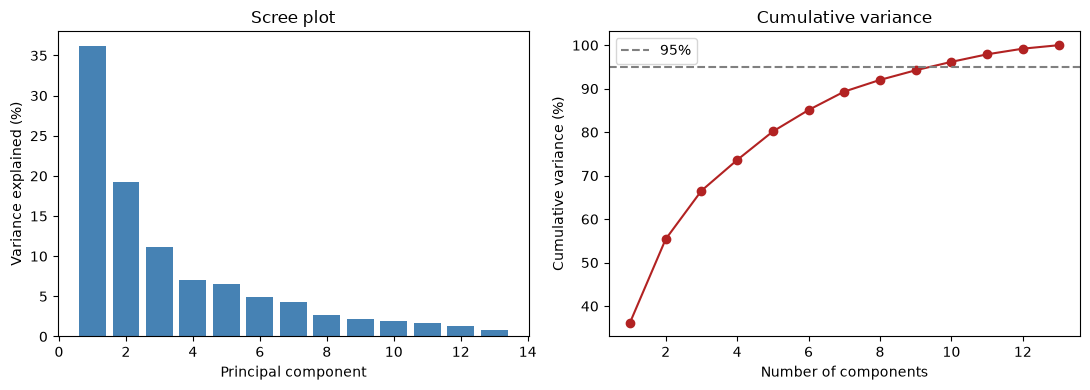

In [4]:
# Scree plot with the cumulative variance curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, len(evr) + 1), evr * 100, color='steelblue')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot')

axes[1].plot(range(1, len(cum) + 1), cum * 100, marker='o', color='firebrick')
axes[1].axhline(95, ls='--', color='grey', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Transform the data onto the principal components
X_pca = pca.transform(X_scaled)
print("Transformed shape:", X_pca.shape, "(13 features -> 13 components)")

# Keep only the first 2 components, which hold 55% of the variance
X_pca2 = X_pca[:, :2]
print("Reduced shape:", X_pca2.shape)

print(pd.DataFrame(X_pca2[:5], columns=['PC1', 'PC2']).round(3))

Transformed shape: (178, 13) (13 features -> 13 components)
Reduced shape: (178, 2)
     PC1    PC2
0  3.317  1.443
1  2.209 -0.333
2  2.517  1.031
3  3.757  2.756
4  1.009  0.870


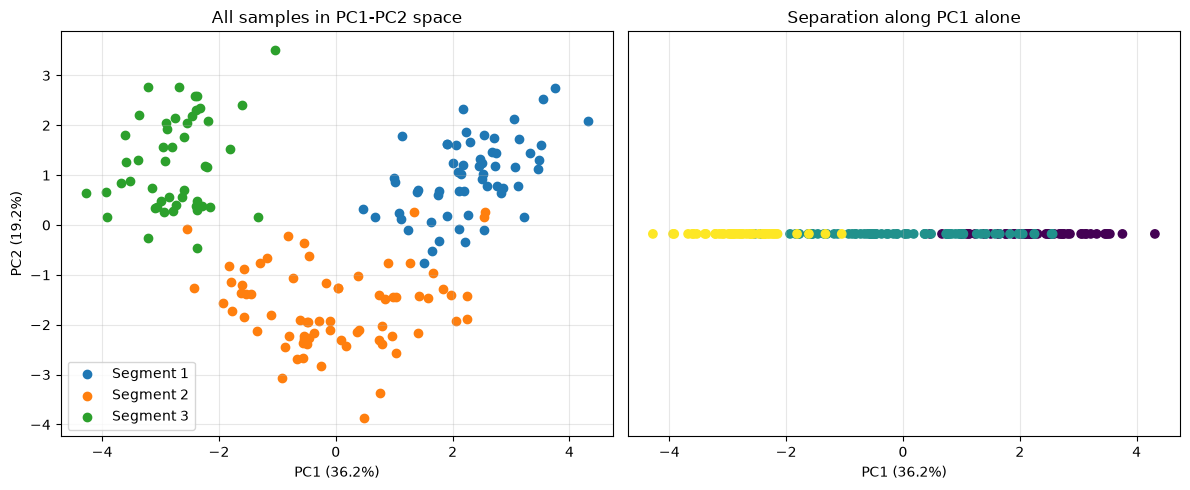

In [6]:
# Inspect PC1 vs PC2 - the segments separate clearly along PC1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for seg in sorted(y.unique()):
    m = (y == seg).values
    axes[0].scatter(X_pca2[m, 0], X_pca2[m, 1], label=f'Segment {seg}')
axes[0].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[0].set_title('All samples in PC1-PC2 space')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(X_pca2[:, 0], np.zeros(len(X_pca2)), c=y, cmap='viridis')
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[1].set_yticks([])
axes[1].set_title('Separation along PC1 alone')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Which measurements drive the first two components?
loadings = pd.DataFrame({
    'PC1': pca.components_[0],
    'PC2': pca.components_[1],
}, index=features)
loadings.loc[loadings['PC1'].abs().nlargest(6).index].round(3)

,PC1,PC2
Flavanoids,0.423,-0.003
Total_Phenols,0.395,0.065
OD280,0.376,-0.164
Proanthocyanins,0.313,0.039
Nonflavanoid_Phenols,-0.299,0.029
Hue,0.297,-0.279


In [8]:
# Does the reduced data still separate the segments? Compare accuracy
# using all 13 features against using only the first 2 components.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

s2 = StandardScaler()
A, B = s2.fit_transform(X_tr), s2.transform(X_te)
p2 = PCA(n_components=2).fit(A)

full_acc = LogisticRegression(max_iter=1000).fit(A, y_tr).score(B, y_te)
pca_acc = LogisticRegression(max_iter=1000).fit(
    p2.transform(A), y_tr).score(p2.transform(B), y_te)

print(f"All 13 features : {full_acc:.4f}")
print(f"First 2 PCs     : {pca_acc:.4f}")

All 13 features : 0.9722
First 2 PCs     : 0.9167
